In [1]:
import gdown
import zipfile
import os

file_id = "1dviMhTU9olu_AkMsDMf3xY3QtRIw_m2v"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

zip_path = "/content/ai2.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print(f"압축 해제 완료")

os.chdir("/content/ai2/ch06")

Downloading...
From (original): https://drive.google.com/uc?id=1dviMhTU9olu_AkMsDMf3xY3QtRIw_m2v
From (redirected): https://drive.google.com/uc?id=1dviMhTU9olu_AkMsDMf3xY3QtRIw_m2v&confirm=t&uuid=e00722a0-bbbd-4417-8bf8-f1a223c9ff4c
To: /content/ai2.zip
100%|██████████| 29.0M/29.0M [00:00<00:00, 33.0MB/s]


압축 해제 완료


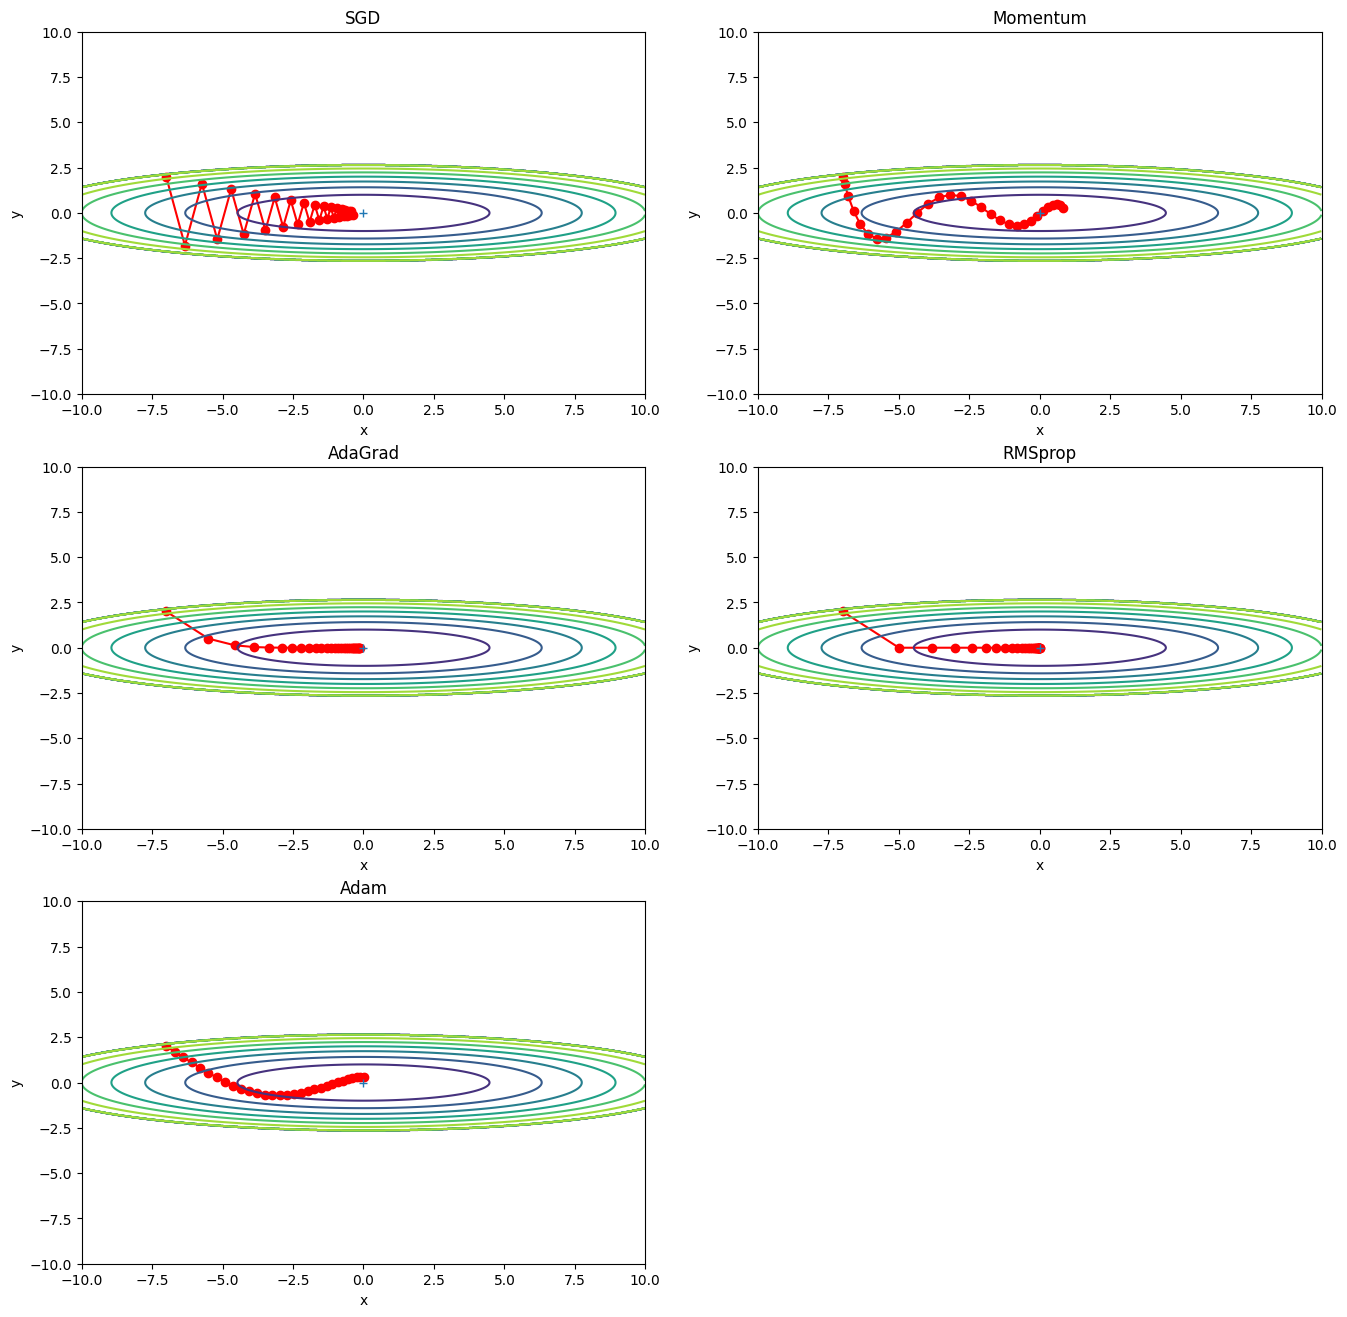

In [2]:
import sys, os
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *

plt.figure(figsize=(16, 16))

# def f(x, y):
#     return x**2  + y**2

# def df(x, y):
#     return 2.0*x , 2.0*y

def f(x, y):
    return x**2 / 20.0 + y**2

def df(x, y):
    return x / 10.0, 2.0*y

# init_pos = (-2.5, 0)
# init_pos = (-2.0, 2.0)

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["RMSprop"] = RMSprop(lr=0.2)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]

    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])

        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)


    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)

    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0

    # 그래프 그리기
    plt.subplot(3, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)

    # plt.ylim(-5, 5)
    # plt.xlim(-5, 5)

    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")

plt.show()

===========iteration:0===========
SGD:2.400077001096556
Momentum:2.3407494853501944
AdaGrad:1.9538686438028683
Adam:2.2615120249256764
===========iteration:100===========
SGD:1.7053053830088505
Momentum:0.24335591066451567
AdaGrad:0.14561605457118482
Adam:0.21492804052971184
===========iteration:200===========
SGD:0.9437986791622054
Momentum:0.27773335288063555
AdaGrad:0.14870552478828486
Adam:0.22025031266423684
===========iteration:300===========
SGD:0.4829449338122294
Momentum:0.17509457214483987
AdaGrad:0.046071740568912514
Adam:0.09931491202577578
===========iteration:400===========
SGD:0.5094934036459827
Momentum:0.17660416389954278
AdaGrad:0.05866627889200171
Adam:0.08725341297691676
===========iteration:500===========
SGD:0.43238351292931726
Momentum:0.21939502395850505
AdaGrad:0.06226926306907253
Adam:0.1624779576015481
===========iteration:600===========
SGD:0.4057366355236338
Momentum:0.1411833648622849
AdaGrad:0.05321842611215491
Adam:0.10977188678634649
===========iteratio

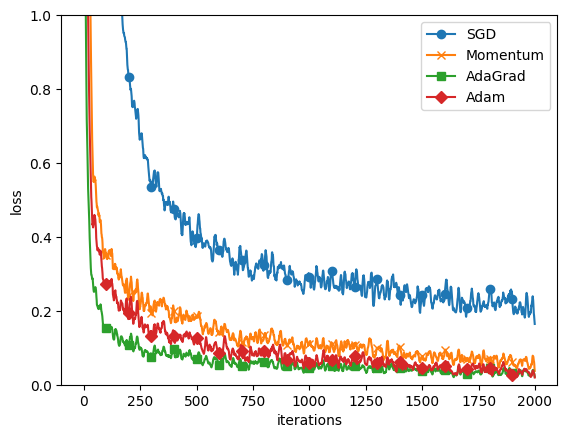

In [3]:
import os
import sys
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)

        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

### numpy random 함수

In [4]:
import numpy as np
a = np.random.randn(1000)
# print(a)
print(np.mean(a))
print(np.std(a))

-0.0029977356516465575
1.0082492546179114


In [5]:
import numpy as np
a = np.random.randn(1000,1000)*0.01
print(np.mean(a))
print(np.std(a))

2.1807804597714453e-05
0.009992963214132356


In [6]:
import numpy as np
a = np.random.uniform(low=-1.0, high=1.0, size=(10,10))
print(np.mean(a))
print(np.std(a))

-0.15435263290085738
0.578274846208334


(1000, 100)


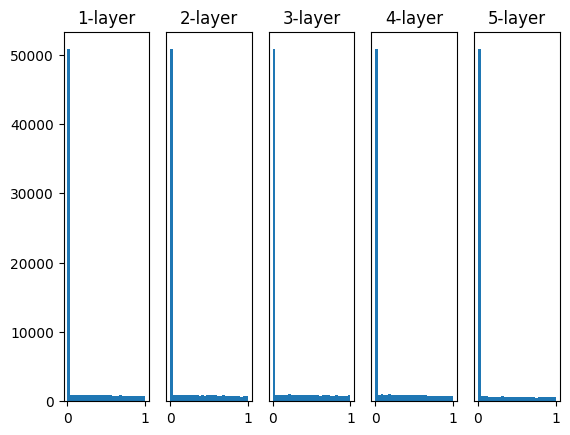

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

input_data = np.random.randn(1000, 100)  # 1000개의 데이터
print(input_data.shape)
node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 초깃값을 다양하게 바꿔가며 실험해보자！
    # w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

# test
#     w = np.random.uniform(low=-2.0, high=2.0, size=(100,100))  * np.sqrt(2.0 / node_num)

    a = np.dot(x, w)
#     print(a)

    # 활성화 함수도 바꿔가며 실험해보자！
    # z = sigmoid(a)
    z = ReLU(a)
#     z = tanh(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

In [8]:
def  foo(a,b,c):
    print(a,b,c)

foo(a=1,c=2,b=3)

1 3 2


===========iteration:0===========
std=0.01:2.3025241516227113
Xavier:2.314438450434239
He:2.412690319935748
===========iteration:100===========
std=0.01:2.302128490885207
Xavier:2.2481094324754
He:1.63072653187057
===========iteration:200===========
std=0.01:2.302722053681514
Xavier:2.192248310324638
He:0.9195329881736073
===========iteration:300===========
std=0.01:2.300071909226472
Xavier:1.951506954989632
He:0.5337887946648056
===========iteration:400===========
std=0.01:2.3016137177036113
Xavier:1.5082684839575067
He:0.38292396005149415
===========iteration:500===========
std=0.01:2.2991225788066245
Xavier:1.0013671365474617
He:0.4496970801293908
===========iteration:600===========
std=0.01:2.2949991804090724
Xavier:0.7304165327858677
He:0.42359717727325485
===========iteration:700===========
std=0.01:2.306026458816215
Xavier:0.61685129708713
He:0.41799654892326077
===========iteration:800===========
std=0.01:2.296508448881969
Xavier:0.3505327354621221
He:0.20712527681345272
======

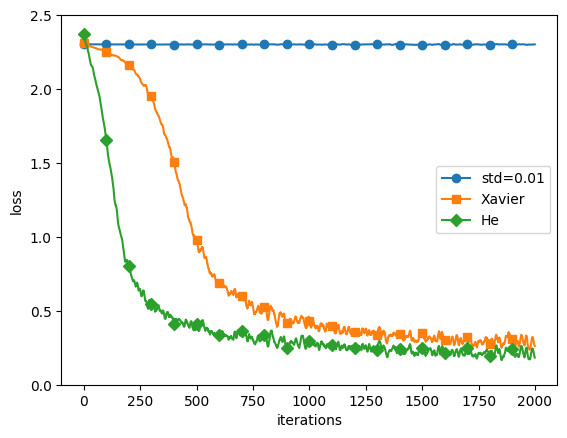

In [9]:
import os
import sys

sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)

        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

### 배치 정규화 테스트

In [10]:
x1 = np.array([1000, 3000, 2000, 5000, 7000])
print(x1)
mean = np.mean(x1)
out  = (x1 - mean)/np.std(x1)
print(out)

[1000 3000 2000 5000 7000]
[-1.2070197  -0.27854301 -0.74278135  0.64993368  1.57841037]


In [11]:
x1 = np.arange(100000)
mean = np.mean(x1)
out  = (x1 - mean)/np.std(x1)
print(np.mean(out))
print(np.std(out))

-3.637978807091713e-17
0.9999999999999999


In [12]:
x1 = np.arange(100000)
mean = np.mean(x1)
out  = (x1 - mean)/np.std(x1)
print(np.mean(out))
print(np.std(out))
gamma = 2
beta = 1
y = out*gamma + beta
print(np.mean(y))
print(np.std(y))

-3.637978807091713e-17
0.9999999999999999
1.0
1.9999999999999998


In [13]:
import sys, os
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend

plt.figure(figsize=(16, 16))
# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100], output_size=10,
                              use_batchnorm=True)

x_batch = x_train[:1]
t_batch = t_train[:1]

grad_backprop = network.gradient(x_batch, t_batch)
grad_numerical = network.numerical_gradient(x_batch, t_batch)


for key in grad_numerical.keys():
    diff = np.average( np.abs(grad_backprop[key] - grad_numerical[key]) )
    print(key + ":" + str(diff))

W1:0.0
b1:0.0
gamma1:0.0
beta1:0.0
W2:0.0
b2:0.0
gamma2:0.0
beta2:0.05188343051301114
W3:0.0
b3:1.7990402263745597e-07


<Figure size 1600x1600 with 0 Axes>

In [14]:
a = np.logspace(0, -4, num=5, base=2)
a

array([1.    , 0.5   , 0.25  , 0.125 , 0.0625])

In [15]:
a = np.logspace(0, 4, num=5, base=10)
a

array([1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])

============== 1/16 ==============
epoch:0 | 0.097 - 0.076
epoch:1 | 0.117 - 0.078
epoch:2 | 0.117 - 0.086
epoch:3 | 0.117 - 0.106
epoch:4 | 0.117 - 0.131
epoch:5 | 0.117 - 0.143
epoch:6 | 0.117 - 0.172
epoch:7 | 0.117 - 0.186
epoch:8 | 0.117 - 0.199
epoch:9 | 0.116 - 0.223
epoch:10 | 0.116 - 0.257
epoch:11 | 0.117 - 0.273
epoch:12 | 0.117 - 0.298
epoch:13 | 0.117 - 0.323
epoch:14 | 0.116 - 0.338
epoch:15 | 0.116 - 0.349
epoch:16 | 0.116 - 0.368
epoch:17 | 0.116 - 0.378
epoch:18 | 0.116 - 0.398
epoch:19 | 0.116 - 0.412
============== 2/16 ==============
epoch:0 | 0.1 - 0.112


/tmp/ipykernel_20970/3908923493.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')
/content/ai2/ch06/../common/multi_layer_net_extend.py:104: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
/content/ai2/ch06/../common/multi_layer_net_extend.py:104: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)


epoch:1 | 0.097 - 0.119
epoch:2 | 0.097 - 0.116
epoch:3 | 0.097 - 0.118
epoch:4 | 0.097 - 0.144
epoch:5 | 0.097 - 0.177
epoch:6 | 0.097 - 0.193
epoch:7 | 0.097 - 0.232
epoch:8 | 0.097 - 0.257
epoch:9 | 0.097 - 0.27
epoch:10 | 0.097 - 0.301
epoch:11 | 0.097 - 0.329
epoch:12 | 0.097 - 0.357
epoch:13 | 0.097 - 0.38
epoch:14 | 0.097 - 0.412
epoch:15 | 0.097 - 0.433
epoch:16 | 0.097 - 0.446
epoch:17 | 0.097 - 0.47
epoch:18 | 0.097 - 0.473
epoch:19 | 0.097 - 0.494
============== 3/16 ==============
epoch:0 | 0.143 - 0.104
epoch:1 | 0.289 - 0.101
epoch:2 | 0.431 - 0.12
epoch:3 | 0.55 - 0.149
epoch:4 | 0.633 - 0.171
epoch:5 | 0.677 - 0.195
epoch:6 | 0.745 - 0.238
epoch:7 | 0.771 - 0.282
epoch:8 | 0.809 - 0.307
epoch:9 | 0.834 - 0.338
epoch:10 | 0.857 - 0.366
epoch:11 | 0.858 - 0.399
epoch:12 | 0.897 - 0.437
epoch:13 | 0.911 - 0.46
epoch:14 | 0.916 - 0.485
epoch:15 | 0.94 - 0.518
epoch:16 | 0.948 - 0.547
epoch:17 | 0.944 - 0.567
epoch:18 | 0.961 - 0.591
epoch:19 | 0.965 - 0.613
============== 4

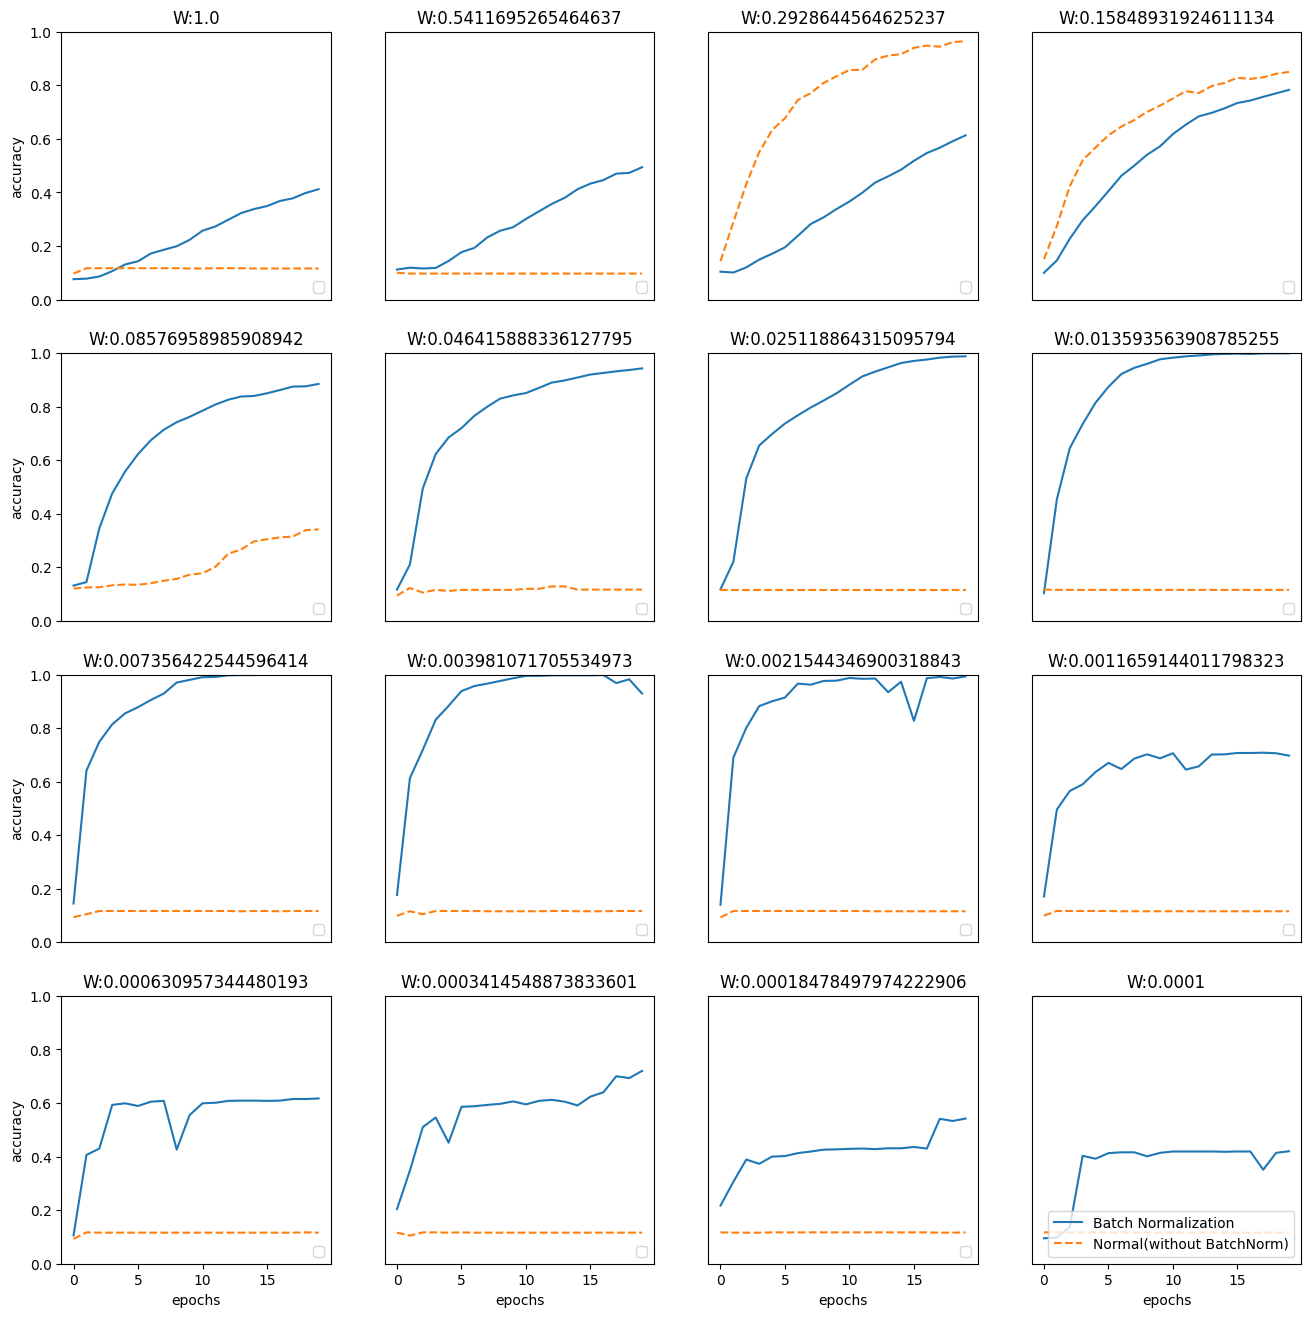

In [16]:
import sys, os
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

plt.figure(figsize=(16, 16))

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list


# 그래프 그리기==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')

plt.show()

epoch:0, train acc:0.09, test acc:0.0746
epoch:1, train acc:0.09666666666666666, test acc:0.0753
epoch:2, train acc:0.12666666666666668, test acc:0.0836
epoch:3, train acc:0.14666666666666667, test acc:0.0983
epoch:4, train acc:0.17666666666666667, test acc:0.1188
epoch:5, train acc:0.21333333333333335, test acc:0.1358
epoch:6, train acc:0.23333333333333334, test acc:0.1494
epoch:7, train acc:0.2633333333333333, test acc:0.1647
epoch:8, train acc:0.2866666666666667, test acc:0.1772
epoch:9, train acc:0.30333333333333334, test acc:0.1934
epoch:10, train acc:0.32, test acc:0.2049
epoch:11, train acc:0.35333333333333333, test acc:0.222
epoch:12, train acc:0.37666666666666665, test acc:0.2378
epoch:13, train acc:0.38666666666666666, test acc:0.2555
epoch:14, train acc:0.42, test acc:0.2742
epoch:15, train acc:0.4166666666666667, test acc:0.2809
epoch:16, train acc:0.42333333333333334, test acc:0.2905
epoch:17, train acc:0.46, test acc:0.305
epoch:18, train acc:0.44666666666666666, test acc

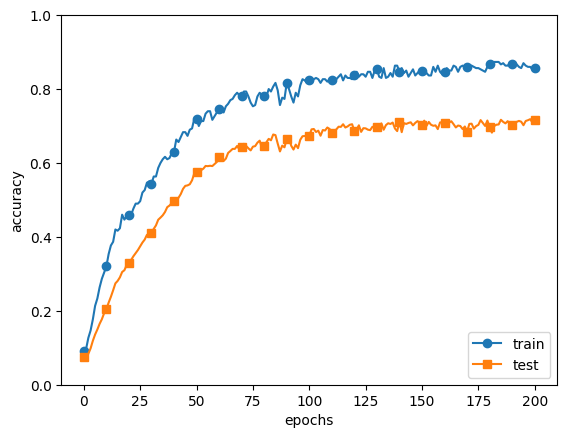

In [17]:
import os
import sys

sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
# weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### 드롭아웃 테스트

#### tuple 언패킹

In [18]:
# a = 1,2
# print(type(a), a)

a,b = (1,2)
print(type(a), a)
print(type(b), b)

<class 'int'> 1
<class 'int'> 2


In [19]:
def foo():
    return 1,2

c = foo()
print(c)

c,d = foo()
print(c,d)

(1, 2)
1 2


In [20]:
def foo(a):
    print(a)

foo(1)

def foo(a,b):
    print(a,b)

c = (1,2)
foo(*c)

1
1 2


In [21]:
import numpy as np
x = (600,500)
# x = (6,5)
# print(x)
# print(*x)
a = np.random.rand(*x)  # np.random.rand(6,5)
print(np.mean(a))
print(np.max(a))
print(np.min(a))
# # print(a)

0.5001032166564964
0.9999996697447816
6.579245990234739e-07


In [22]:
import numpy as np
x = np.arange(1,31).reshape((6,5))
print(x)
print(x.shape)
mask = np.random.rand(*x.shape)
print(mask)
mask = mask > 0.2
print(mask)
print(mask.shape)
# # # print(np.mean(mask))
print(x * mask)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]
 [26 27 28 29 30]]
(6, 5)
[[0.10329937 0.32303794 0.61184022 0.06753184 0.46482611]
 [0.32794719 0.37982642 0.23257622 0.73931722 0.10197127]
 [0.42669052 0.13235199 0.01594165 0.68765888 0.236436  ]
 [0.27659996 0.67112459 0.04337295 0.11351638 0.03864401]
 [0.6953875  0.31227942 0.774723   0.25428717 0.79339958]
 [0.2675243  0.42019881 0.08995712 0.42513925 0.14367941]]
[[False  True  True False  True]
 [ True  True  True  True False]
 [ True False False  True  True]
 [ True  True False False False]
 [ True  True  True  True  True]
 [ True  True False  True False]]
(6, 5)
[[ 0  2  3  0  5]
 [ 6  7  8  9  0]
 [11  0  0 14 15]
 [16 17  0  0  0]
 [21 22 23 24 25]
 [26 27  0 29  0]]


train loss:2.3100820867259646
=== epoch:1, train acc:0.11333333333333333, test acc:0.0828 ===
train loss:2.2935306281009376
train loss:2.314131797696105
train loss:2.316088147045318
=== epoch:2, train acc:0.11333333333333333, test acc:0.0846 ===
train loss:2.330111226999291
train loss:2.3209594375129297
train loss:2.3276430984772474
=== epoch:3, train acc:0.11666666666666667, test acc:0.0853 ===
train loss:2.3149568868559376
train loss:2.326317141783506
train loss:2.2858301290811585
=== epoch:4, train acc:0.11666666666666667, test acc:0.0838 ===
train loss:2.3002041989528816
train loss:2.3070827174340156
train loss:2.316818052773883
=== epoch:5, train acc:0.12, test acc:0.0856 ===
train loss:2.305314998808628
train loss:2.314213747295392
train loss:2.2967628188027365
=== epoch:6, train acc:0.12, test acc:0.0859 ===
train loss:2.3126939202026535
train loss:2.294938645809171
train loss:2.320896872706388
=== epoch:7, train acc:0.12, test acc:0.0877 ===
train loss:2.2846605317358724
train 

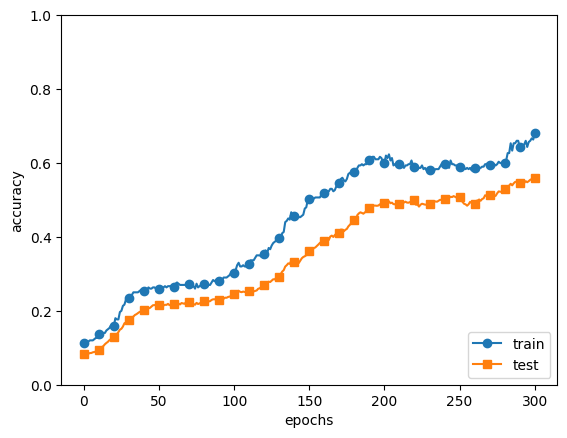

In [23]:
import os
import sys
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# 드롭아웃 사용 유무와 비울 설정 ========================
use_dropout = True  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()